# 3. Grading forecasts and sizing bets

**What this notebook answers:** (a) how do we tell whether a probability forecaster is any good,
and (b) once we believe we have an edge, how much should we bet?

> **A note on the data.** Grading needs *resolved* events, and Fed meetings resolve only eight
> times a year. Until the scraper has collected enough history, the grading examples use
> **synthetic forecasters** (simulated, clearly labelled) so you can see how each tool behaves
> when you know the right answer. The sizing section at the end uses the real October quotes.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _style as st
from pmq.eval import scoring
from pmq.risk import kelly
from pmq.pricing import clean

st.setup()
rng = np.random.default_rng(7)

## 3.1 Two ways to score a probability

A single "70%" forecast is neither right nor wrong: if the event fails to happen, that is what
you'd expect 30% of the time. So we grade forecasters **over many events** with a *scoring rule*.
Lower is better for both rules below.

**Log loss** is minus the log of the probability you gave to what actually happened:

$$\text{log loss} = -\ln(p_{\text{given to the actual outcome}})$$

**Brier score** is the squared gap between forecast and outcome (1 if it happened, else 0):

$$\text{Brier} = (p - y)^2 .$$

The important difference: log loss punishes confident misses *savagely*. Saying 1% about something
that happens costs 4.6 in log loss but only 0.98 in Brier. Both charts below show the penalty
when the event **does** happen, as a function of the probability you gave it.

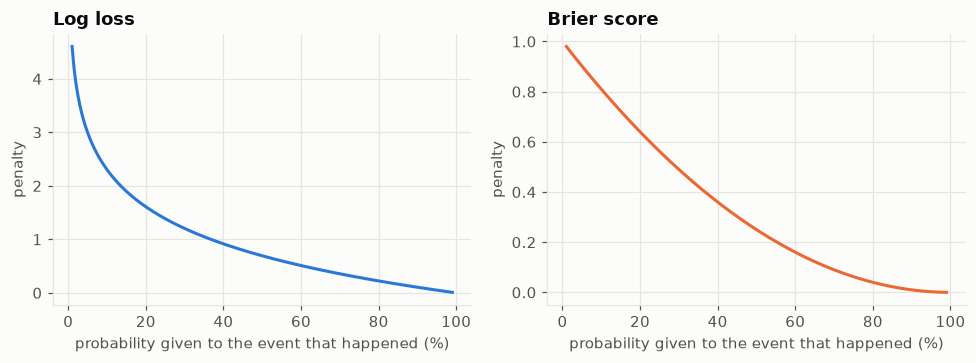

In [2]:
p = np.linspace(0.01, 0.99, 197)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].plot(p * 100, -np.log(p), color=st.BLUE); axes[0].set_title("Log loss")
axes[1].plot(p * 100, (1 - p) ** 2, color=st.ORANGE); axes[1].set_title("Brier score")
for a in axes: a.set_xlabel("probability given to the event that happened (%)"); a.set_ylabel("penalty")
plt.tight_layout(); plt.show()

## 3.2 Why these are "proper": honesty is the best policy

A scoring rule is **proper** if the best average score comes from reporting your *true* belief.
Nobody gains by exaggerating or hedging. We can check that by simulation: the event truly has a
70% chance; try reporting every value from 0 to 100% and see where the average penalty is lowest.

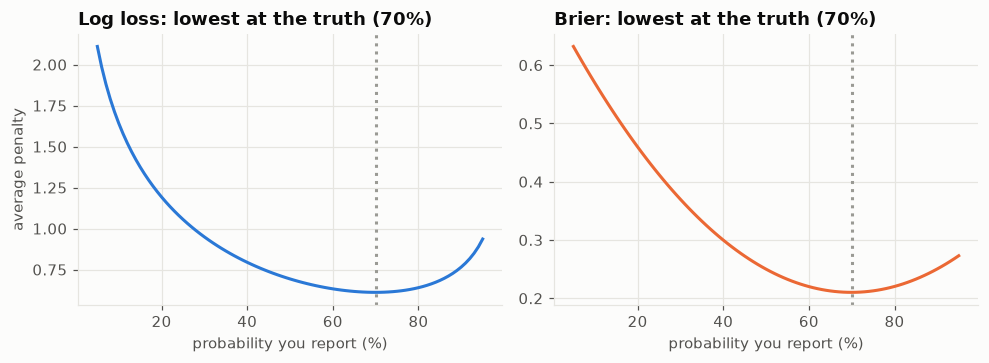

In [3]:
truth = 0.70
outcomes = (rng.random(200_000) < truth).astype(float)
grid = np.linspace(0.05, 0.95, 91)
ll = [scoring.log_loss(np.full_like(outcomes, g), outcomes) for g in grid]
br = [scoring.brier(np.full_like(outcomes, g), outcomes) for g in grid]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for a, vals, name, colour in [(axes[0], ll, "Log loss", st.BLUE), (axes[1], br, "Brier", st.ORANGE)]:
    a.plot(grid * 100, vals, color=colour); a.axvline(70, color=st.GREY, ls=":")
    a.set_title(f"{name}: lowest at the truth (70%)"); a.set_xlabel("probability you report (%)")
axes[0].set_ylabel("average penalty")
plt.tight_layout(); plt.show()

## 3.3 Calibration: do "70%" events happen 70% of the time?

A calibrated forecaster's 70% calls come true about 70% of the time. We check by bucketing
forecasts and comparing **what was said** with **what happened**: the *reliability diagram*.
A perfectly calibrated forecaster sits on the diagonal.

Two **synthetic** forecasters see the same events. One reports the true probability. The other
is **over-confident**: it stretches its probabilities toward 0 and 100.

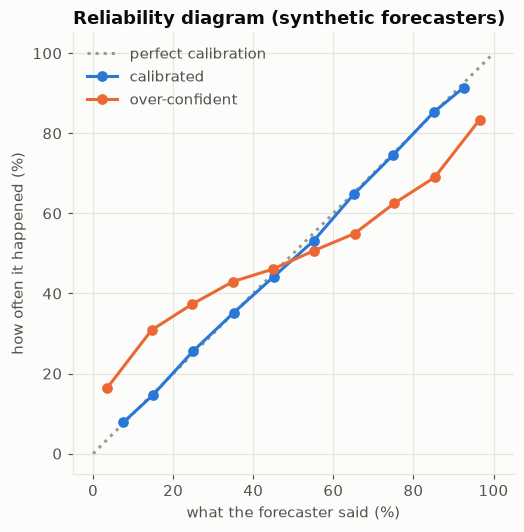

In [4]:
n = 20_000
true_p = rng.uniform(0.05, 0.95, n)
y = (rng.random(n) < true_p).astype(float)
calibrated = true_p
overconfident = 1 / (1 + np.exp(-2.2 * np.log(true_p / (1 - true_p))))

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot([0, 100], [0, 100], color=st.GREY, ls=":", label="perfect calibration")
for name, f, colour in [("calibrated", calibrated, st.BLUE), ("over-confident", overconfident, st.ORANGE)]:
    tab = pd.DataFrame(scoring.reliability_table(f, y, bins=10))
    ax.plot(tab["mean_forecast"] * 100, tab["frequency"] * 100, "o-", color=colour, label=name)
ax.set_xlabel("what the forecaster said (%)"); ax.set_ylabel("how often it happened (%)")
ax.set_title("Reliability diagram (synthetic forecasters)"); ax.legend(loc="upper left"); ax.set_aspect("equal")
plt.show()

The over-confident forecaster's curve is flatter than the diagonal: when it says 90%, the event
happens noticeably less often than that, and when it says 5%, more often. Two numbers summarise the picture.

**Calibration slope.** Fit $\text{logit}(P(\text{event})) = a + b \cdot \text{logit}(\text{forecast})$.
A calibrated forecaster has $a = 0$, $b = 1$. **A slope below 1 means over-confident** (pull forecasts toward 50%).

**Brier decomposition.** The Brier score splits into three parts (Murphy, 1973):

$$\text{Brier} = \underbrace{\text{reliability}}_{\text{calibration error, lower is better}} - \underbrace{\text{resolution}}_{\text{separating easy from hard events, higher is better}} + \underbrace{\text{uncertainty}}_{\text{fixed by the world}}$$

In [5]:
rows = []
for name, f in [("calibrated", calibrated), ("over-confident", overconfident)]:
    a, b = scoring.calibration_slope_intercept(f, y)
    d = scoring.brier_decomposition(f, y)
    rows.append({"forecaster (synthetic)": name, "log loss": scoring.log_loss(f, y), "Brier": scoring.brier(f, y),
                 "slope (want 1)": b, "reliability": d.reliability, "resolution": d.resolution})
pd.DataFrame(rows).set_index("forecaster (synthetic)").round(4)

,log loss,Brier,slope (want 1),reliability,resolution
forecaster (synthetic),,,,,
calibrated,0.5476,0.1844,0.9857,0.0001,0.0651
over-confident,0.6479,0.2010,0.4481,0.0159,0.0634


## 3.4 Is model A *really* better than the market?

Suppose our model scored slightly better than the market on 60 events. Was that skill or luck?
The **paired bootstrap** answers it. Take the per-event losses of both forecasters on the *same*
events. Re-draw events with replacement 5,000 times, and see how much the average difference
wobbles. If the 95% range excludes 0, the gap is unlikely to be luck.

Below, a small edge that is *not* provable with 60 events, and the same edge with 600.

In [6]:
def compare(n_events, seed=1):
    r = np.random.default_rng(seed)
    t = r.uniform(0.1, 0.9, n_events)
    yy = (r.random(n_events) < t).astype(float)
    market = np.clip(t + r.normal(0, 0.10, n_events), 0.02, 0.98)
    model = np.clip(t + r.normal(0, 0.07, n_events), 0.02, 0.98)   # slightly better (synthetic)
    return scoring.paired_bootstrap_difference(scoring.log_loss_each(model, yy), scoring.log_loss_each(market, yy))

rows = []
for n_events in (60, 600):
    diff, lo, hi = compare(n_events)
    rows.append({"events": n_events, "model - market log loss": diff, "95% low": lo, "95% high": hi,
                 "clearly better?": "yes" if hi < 0 else "cannot tell"})
pd.DataFrame(rows).set_index("events").round(4)

,model - market log loss,95% low,95% high,clearly better?
events,,,,
60,0.0131,-0.1000,0.1140,cannot tell
600,-0.0284,-0.0544,-0.0034,yes


This is why the plan reports **confidence intervals on every score**. With only a handful of Fed meetings
a year, the honest answer will often be "cannot tell yet", and that is a result, not a failure.

## 3.5 How much to bet: the Kelly criterion

You believe an event has probability $p$. The market sells a Yes contract at price $c$. If you
stake a fraction $f$ of your bankroll, your wealth after the bet is multiplied by

* $1 + f\,\frac{1-c}{c}$ if you win, and
* $1 - f$ if you lose.

Kelly's idea is to choose $f$ to maximise the **average growth rate of the logarithm of wealth**. The answer is

$$f^{*} = \frac{p - c}{1 - c}.$$

*Example:* you think 60%, the price is 50 cents, so $f^* = 0.10/0.50 = 20\%$ of your bankroll.
Betting less wastes the edge; betting more is *worse*, and above twice Kelly the average growth is negative.

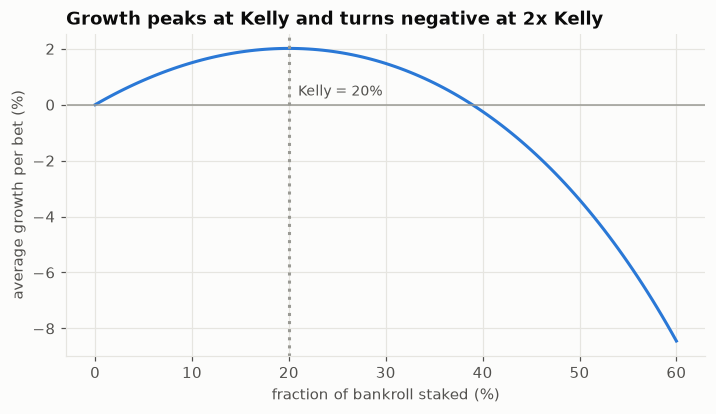

In [7]:
p_belief, price = 0.60, 0.50
f_star = kelly.kelly_fraction(p_belief, price)
f = np.linspace(0, 0.6, 121)
growth = [kelly.expected_log_growth(x, p_belief, price) * 100 for x in f]

fig, ax = plt.subplots()
ax.plot(f * 100, growth, color=st.BLUE)
ax.axhline(0, color=st.GREY, lw=1)
ax.axvline(f_star * 100, color=st.GREY, ls=":")
ax.annotate(f"Kelly = {f_star:.0%}", (f_star * 100, 0), xytext=(6, 6), textcoords="offset points", fontsize=9, color=st.INK_SOFT)
ax.set_xlabel("fraction of bankroll staked (%)"); ax.set_ylabel("average growth per bet (%)")
ax.set_title("Growth peaks at Kelly and turns negative at 2x Kelly")
plt.show()

### Why people bet *less* than Kelly

Full Kelly assumes your $p$ is exactly right, and it is a bumpy ride. Betting a fraction of Kelly gives
up little growth but sharply cuts the chance of a deep loss. A standard approximation for the
probability that your bankroll *ever* falls to a fraction $x$ of its previous peak, when you bet $\lambda \times$ Kelly, is

$$P(\text{ever drop to } x \text{ of peak}) \approx x^{\,2/\lambda - 1}.$$

In [8]:
rows = []
full = kelly.expected_log_growth(f_star, p_belief, price)
for lam in (1.0, 0.75, 0.5, 0.25):
    rows.append({"bet size": f"{lam:g} x Kelly",
                 "share of full-Kelly growth": kelly.expected_log_growth(lam * f_star, p_belief, price) / full,
                 "chance of ever halving": kelly.drawdown_probability(lam, 0.5)})
pd.DataFrame(rows).set_index("bet size").round(3)

,share of full-Kelly growth,chance of ever halving
bet size,,
1 x Kelly,1.000,0.500
0.75 x Kelly,0.936,0.315
0.5 x Kelly,0.747,0.125
0.25 x Kelly,0.435,0.008


**Half-Kelly keeps about 75% of the growth and cuts the chance of ever halving your bankroll from
50% to about 12.5%.** That is why it is the practical default.

> **A common misconception, corrected.** It is tempting to say "my model is uncertain, so I should shrink my
> Kelly bet by the model's variance". For a *single* bet with log-utility that is **not** true:
> expected growth is a straight line in $p$, so sizing on the *average* of your uncertain $p$ is
> already optimal. What protects you from an over-confident model is **pooling it toward the
> market and checking its calibration** (notebooks 2 and 3.3), plus fractional Kelly for drawdown
> control. The project follows that rule.

### Fees change the maths

A fee raises the price you effectively pay, from $c$ to $c + \text{fee}(c)$. So your *edge must
exceed the fee before Kelly stakes anything*. Reusing the 60% belief at a 50-cent price:

In [9]:
from pmq.pricing import fees
for belief in (0.505, 0.52, 0.55, 0.60):
    eff = fees.cost_to_buy_yes(0.50)
    f_net = max(0.0, kelly.kelly_fraction(belief, eff))
    print(f"belief {belief:.1%}: edge {100 * (belief - 0.50):.1f} c, fee {100 * fees.taker_fee(0.50):.2f} c -> Kelly stake {f_net:.1%} of bankroll")

belief 50.5%: edge 0.5 c, fee 1.75 c -> Kelly stake 0.0% of bankroll
belief 52.0%: edge 2.0 c, fee 1.75 c -> Kelly stake 0.5% of bankroll
belief 55.0%: edge 5.0 c, fee 1.75 c -> Kelly stake 6.7% of bankroll
belief 60.0%: edge 10.0 c, fee 1.75 c -> Kelly stake 17.1% of bankroll


A 0.5-point edge disappears entirely once the 1.75 cent fee is paid.

## 3.6 Several outcomes at once

For a multi-outcome market (exactly one of Cut / Hold / Hike happens) the bets interact: money
staked on one outcome is lost if another happens. Kelly still applies. We maximise the average of
$\ln(\text{wealth})$ over all stakes at once, where wealth if outcome $j$ occurs is

$$W_j = 1 - \sum_i f_i + \frac{f_j}{c_j}.$$

Below: the real October Polymarket prices against an **illustrative** personal belief that shifts
probability from "Hike 25" to "No change".

In [10]:
poly, kal, rules = st.load_fomc()
prices = poly["mid"].to_numpy()
belief_vec = np.array([0.005, 0.005, 0.55, 0.43, 0.01])           # ILLUSTRATIVE belief; adds to 1
stakes = kelly.kelly_mutually_exclusive(belief_vec, prices)
table = pd.DataFrame({"outcome": poly["label"], "market price": prices, "my belief (illustrative)": belief_vec,
                      "Kelly stake (% of bankroll)": stakes * 100}).set_index("outcome")
table.round(3)

,market price,my belief (illustrative),Kelly stake (% of bankroll)
outcome,,,
50+ bps decrease,0.004,0.005,0.225
25 bps decrease,0.006,0.005,0.068
No change,0.435,0.550,20.830
25 bps increase,0.555,0.430,0.000
50+ bps increase,0.008,0.010,0.334


The solver stakes on "No change" (where the belief exceeds the price) and stays away from the rest.
The prices here add to more than 1, so part of every outcome's apparent value is the venue's cushion, and
that is one more reason the pricing notebook removes the overround **before** calling anything an edge.

## Recap

* **Proper scoring rules** (log loss, Brier) reward honesty; grade over many events and against the market as baseline.
* **Reliability diagrams and calibration slope** show *how* a forecaster is wrong (over-confidence, bias).
* **Paired bootstrap** tells us whether a gap is skill or luck. Small samples often say "cannot tell".
* **Kelly** gives the growth-maximising stake, $f^* = (p-c)/(1-c)$. Fractional Kelly trades a little growth for a lot less drawdown.
* **Fees and overround** must be netted out before an edge counts.